In [3]:
import pandas as pd
df = pd.read_csv('online_retail_data.csv')
df

,Order ID,Amount,Profit,Quantity,Category,Sub-Category,Payment Mode,Order Date,Customer Name,State
0,OD1000,50000.000000,296.426650,2,Electronics,Accessories,NaN,29/06/2023,Customer_33,Delhi
1,OD1001,-100.000000,148.437902,1,Clothing,T-shirts,NaN,2023-01-16,Customer_45,Delhi
2,OD1002,99999.000000,200.216812,4,Electronics,Accessories,NaN,2024-01-15,Customer_15,Tamil Nadu
3,OD1003,4881.577691,1113.833182,5,Clothing,Jeans,UPI,2023-06-17,Customer_39,Gujarat
4,OD1004,964.356808,-89.406744,4,Electronics,Phones,UPI,2024-05-13,Customer_15,Maharashtra
...,...,...,...,...,...,...,...,...,...,...
495,OD1495,937.953896,-14.817068,5,Electronics,Phones,Credit Card,2023-03-27,Customer_19,Delhi
496,OD1496,2522.079856,460.708866,2,Furniture,Bookcases,Credit Card,2023-10-29,Customer_6,Tamil Nadu
497,OD1497,313.191805,-9.490538,3,Furniture,Tables,COD,2023-12-09,Customer_6,Delhi
498,OD1498,989.373320,NaN,2,Electronics,Accessories,Credit Card,2023-03-30,Customer_2,Karnataka


In [4]:
import seaborn as sns
import matplotlib.pyplot as plt


In [19]:
import pandas as pd
import numpy as np
import time



df.to_csv('online_retail_data.csv')

# Handling missing values

In [21]:
profit_median = df['Profit'].median()
df['Profit'] = df['Profit'].fillna(profit_median)

payment_mode = df['Payment Mode'].mode()[0]
df['Payment Mode'] = df['Payment Mode'].fillna(payment_mode)

df

,Order ID,Amount,Profit,Quantity,Category,Sub-Category,Payment Mode,Order Date,Customer Name,State,year,Month,Quarter,Year
0,OD1000,50000.000000,296.426650,2,Electronics,Accessories,Credit Card,2026-01-19 23:00:07,Customer_33,Delhi,NaN,1,1,2026
1,OD1001,-100.000000,148.437902,1,Clothing,T-shirts,Credit Card,2025-12-19 00:14:34,Customer_45,Delhi,NaN,12,4,2025
2,OD1002,99999.000000,200.216812,4,Electronics,Accessories,Credit Card,2026-02-01 16:25:17,Customer_15,Tamil Nadu,NaN,2,1,2026
3,OD1003,4881.577691,1113.833182,5,Clothing,Jeans,UPI,2026-02-08 02:41:08,Customer_39,Gujarat,NaN,2,1,2026
4,OD1004,964.356808,-89.406744,4,Electronics,Phones,UPI,2025-12-28 02:53:54,Customer_15,Maharashtra,NaN,12,4,2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,OD1495,937.953896,-14.817068,5,Electronics,Phones,Credit Card,2026-02-10 09:22:07,Customer_19,Delhi,NaN,2,1,2026
496,OD1496,2522.079856,460.708866,2,Furniture,Bookcases,Credit Card,2026-01-20 00:34:35,Customer_6,Tamil Nadu,NaN,1,1,2026
497,OD1497,313.191805,-9.490538,3,Furniture,Tables,COD,2026-01-12 18:43:52,Customer_6,Delhi,NaN,1,1,2026
498,OD1498,989.373320,125.274550,2,Electronics,Accessories,Credit Card,2026-01-03 14:53:35,Customer_2,Karnataka,NaN,1,1,2026


# Noisy data and outliers

In [22]:
df = df[df['Amount'] > 0]

In [23]:
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + 1.5 * IQR

/var/folders/lz/892knn6x463c033glm9wvqm00000gn/T/ipykernel_95995/2118995455.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Amount'] = np.where(df['Amount'] > upper_limit, upper_limit, df['Amount'])


Text(0.5, 1.0, 'Cleaned Distribution of Order Amount')

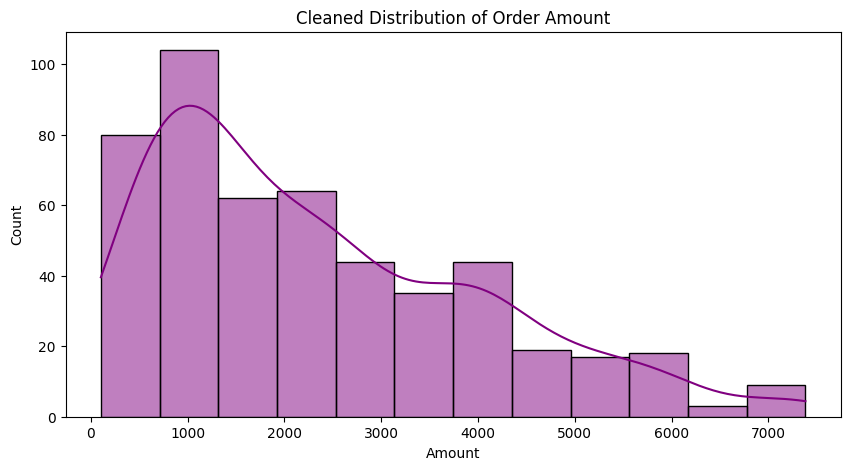

In [ ]:
df['Amount'] = np.where(df['Amount'] > upper_limit, upper_limit, df['Amount'])
plt.figure(figsize=(10, 5))
sns.histplot(df['Amount'], kde=True, color='purple')
plt.title("Cleaned Distribution of Order Amount")
plt.show()

# data transformation:

In [ ]:
# Calculate Profit Margin percentage
df['Profit_Margin'] = (df['Profit'] / df['Amount']) * 100

print("Feature Engineering: 'Profit_Margin' column added.")
print(df[['Amount', 'Profit', 'Profit_Margin']].head())

Feature Engineering: 'Profit_Margin' column added.
        Amount       Profit  Profit_Margin
0  7383.727233   296.426650       4.014594
2  7383.727233   200.216812       2.711595
3  4881.577691  1113.833182      22.817074
4   964.356808   -89.406744      -9.271127
5  2108.518273    76.433424       3.624983


/var/folders/lz/892knn6x463c033glm9wvqm00000gn/T/ipykernel_95995/807381931.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Profit_Margin'] = (df['Profit'] / df['Amount']) * 100


# Sales performance analysis

                    Amount        Profit
Category                                
Electronics  416517.256604  34704.302033
Clothing     411102.173093  43720.634876
Furniture    346452.112969  33814.274860


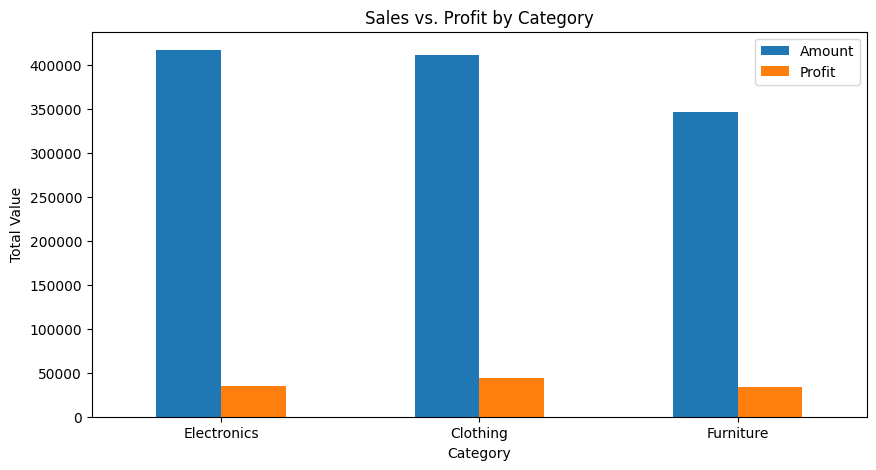

In [29]:
# Grouping by Category to see total Sales and Profit
performance = df.groupby('Category')[['Amount', 'Profit']].sum().sort_values(by='Amount', ascending=False)
print(performance)
# Visualization
performance.plot(kind='bar', figsize=(10, 5), color=['#1f77b4', '#ff7f0e'])
plt.title("Sales vs. Profit by Category")
plt.ylabel("Total Value")
plt.xticks(rotation=0)
plt.show()

# Customer retension analysis

Total Customers: 49
Retention Rate: 97.96%


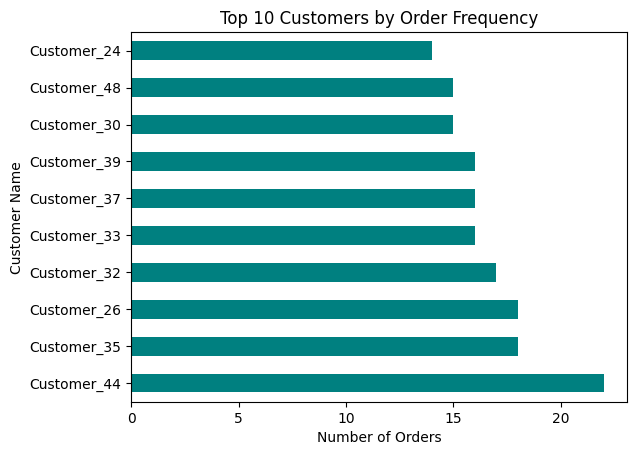

In [32]:
# Counting orders per customer
customer_counts = df['Customer Name'].value_counts()

# Retention: Customers with more than 1 order
retained_customers = customer_counts[customer_counts > 1].count()
total_customers = customer_counts.count()
retention_rate = (retained_customers / total_customers) * 100

print(f"Total Customers: {total_customers}")
print(f"Retention Rate: {retention_rate:.2f}%")

# Visualize top 10 loyal customers
customer_counts.head(10).plot(kind='barh', color='teal')
plt.title("Top 10 Customers by Order Frequency")
plt.xlabel("Number of Orders")
plt.show()

# Gegraphical sales analysis

State
Karnataka        150956.163746
Gujarat          169443.142478
Uttar Pradesh    194595.161797
Maharashtra      195856.140324
Delhi            229105.186849
Tamil Nadu       234115.747473
Name: Amount, dtype: float64


/var/folders/lz/892knn6x463c033glm9wvqm00000gn/T/ipykernel_95995/2182083536.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=geo_sales.values, y=geo_sales.index, palette='magma')


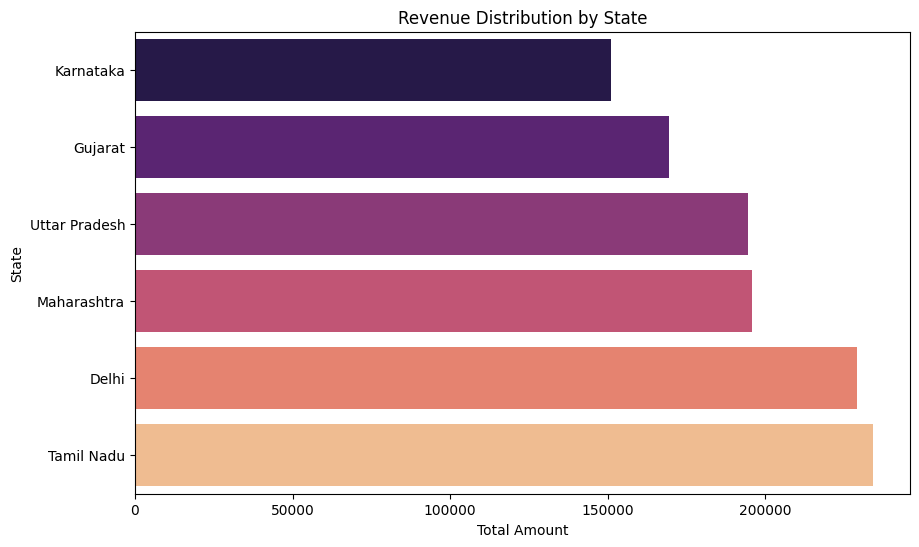

In [34]:
# Grouping by State
geo_sales = df.groupby('State')['Amount'].sum().sort_values()
print(geo_sales)
plt.figure(figsize=(10, 6))
sns.barplot(x=geo_sales.values, y=geo_sales.index, palette='magma')
plt.title("Revenue Distribution by State")
plt.xlabel("Total Amount")
plt.show()

# Visualization insights

In [36]:
# 1. Composition Analysis: The Treemap

import plotly.express as px

# Aggregating data for hierarchy
fig = px.treemap(df, path=['Category', 'Sub-Category'], values='Amount',
                 color='Profit', color_continuous_scale='RdYlGn',
                 title='Market Composition: Sales Volume by Category and Sub-Category')
fig.show()

# relationship and correlation

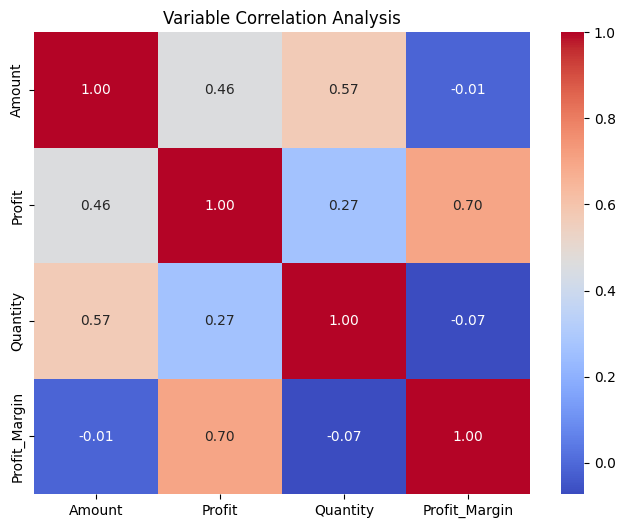

In [37]:
plt.figure(figsize=(8, 6))
correlation_matrix = df[['Amount', 'Profit', 'Quantity', 'Profit_Margin']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Variable Correlation Analysis")
plt.show()

# Distribution plot

/var/folders/lz/892knn6x463c033glm9wvqm00000gn/T/ipykernel_95995/2307332312.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




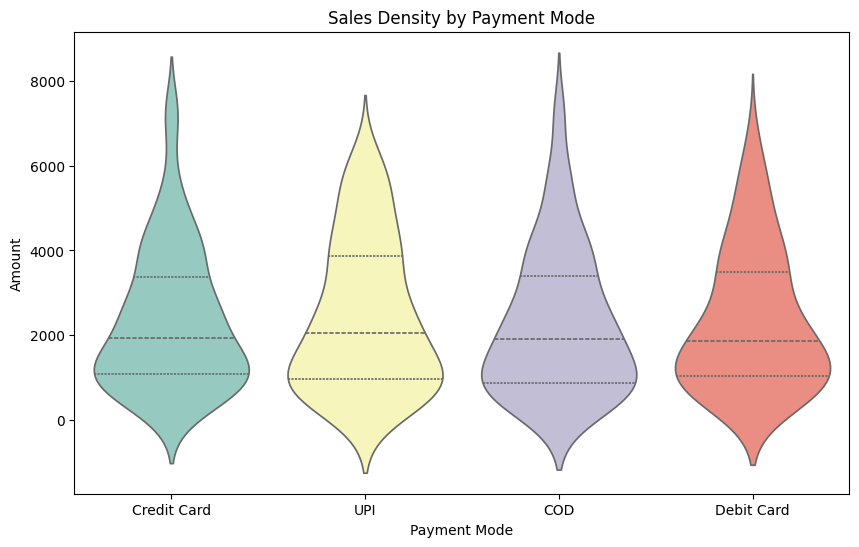

In [38]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='Payment Mode', y='Amount', data=df, inner="quartile", palette="Set3")
plt.title("Sales Density by Payment Mode")
plt.show()

# AB TESTING HYPOTHESES TESTING

In [39]:
from scipy import stats

credit = df[df['Payment Mode'] == 'Credit Card']['Amount']
debit = df[df['Payment Mode'] == 'Debit Card']['Amount']

t_stat, p_val = stats.ttest_ind(credit, debit)

print(f"P-value: {p_val:.4f}")
if p_val < 0.05:
    print("Significant Result: Promote Credit Card usage to increase order value.")
else:
    print("No significant difference: Payment-specific promotions may not work.")

P-value: 0.9617
No significant difference: Payment-specific promotions may not work.


# STATISTICAL TESTING

In [40]:
from scipy import stats

credit = df[df['Payment Mode'] == 'Credit Card']['Amount']
debit = df[df['Payment Mode'] == 'Debit Card']['Amount']

t_stat, p_val = stats.ttest_ind(credit, debit)

print(f"P-value: {p_val:.4f}")
if p_val < 0.05:
    print("Significant Result: Promote Credit Card usage to increase order value.")
else:
    print("No significant difference: Payment-specific promotions may not work.")

P-value: 0.9617
No significant difference: Payment-specific promotions may not work.


In [41]:
from scipy.stats import chi2_contingency

# Step 1: Create a Contingency Table (Cross-tabulation)
contingency_table = pd.crosstab(df['State'], df['Category'])

# Step 2: Perform the Chi-Square Test
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("--- Chi-Square Test Results ---")
print(f"Chi-Square Statistic: {chi2:.2f}")
print(f"P-value: {p:.4f}")

# Step 3: Interpretation
if p < 0.05:
    print("Result: Significant association! Geography influences buying habits.")
    # Visualizing the relationship with a Heatmap
    plt.figure(figsize=(10, 6))
    sns.heatmap(contingency_table, annot=True, cmap="YlGnBu", fmt='d')
    plt.title("State vs. Category Preference Heatmap")
    plt.show()
else:
    print("Result: No significant association. Preferences are uniform across states.")

--- Chi-Square Test Results ---
Chi-Square Statistic: 4.60
P-value: 0.9160
Result: No significant association. Preferences are uniform across states.


In [42]:
from scipy.stats import f_oneway

# Step 1: Prepare data groups (filtering out NaNs)
groups = df.groupby('Payment Mode')['Profit_Margin']

# Extracting individual lists for each category
group_data = [group for name, group in groups]

# Step 2: Perform One-Way ANOVA
f_stat, p_val = f_oneway(*group_data)

print("\n--- ANOVA Results ---")
print(f"F-Statistic: {f_stat:.2f}")
print(f"P-value: {p_val:.4f}")

# Step 3: Visual Confirmation with a Boxplot
if p_val < 0.05:
    print("Result: Payment mode significantly impacts Profit Margin. Action recommended.")
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Payment Mode', y='Profit_Margin', data=df, palette='Set2')
    plt.title("Profit Margin Distribution by Payment Mode")
    plt.axhline(df['Profit_Margin'].mean(), color='red', linestyle='--', label='Global Mean')
    plt.legend()
    plt.show()
else:
    print("Result: No significant difference. Profit margins are consistent across payment modes.")


--- ANOVA Results ---
F-Statistic: 1.44
P-value: 0.2308
Result: No significant difference. Profit margins are consistent across payment modes.
